# Trabajo Práctico N°1
## Problema 1: Clasificación Binaria

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

Construir un modelo de red neuronal que prediga si un paciente tiene alto riesgo de padecer un accidente cerebrovascular (ACV) o no, a partir de sus datos clínicos y demográficos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              mean_squared_error, r2_score,
                              accuracy_score, roc_auc_score)
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_curve, auc

from sklearn.impute import KNNImputer

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [70]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [71]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [73]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


###  Análisis Exploratorio de Datos (EDA)

**División cruzada train - test**

In [74]:
X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 4088
Test size: 1022


**Visualización de datos** (previo a la imputación)

In [75]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

show_num = X_train[numerical_cols].copy()
show_num['stroke'] = y_train.values

C:\Users\juana\AppData\Local\Temp\ipykernel_3992\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


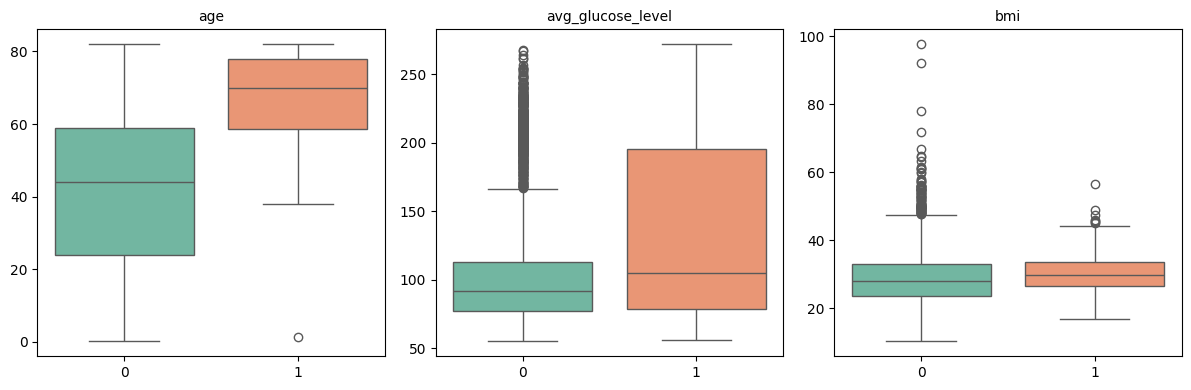

In [76]:
cols = 4
num_vars = len(show_num.columns) - 1 
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns[:-1]): 
    sns.boxplot(
        data=show_num,
        x='stroke',
        y=var, 
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

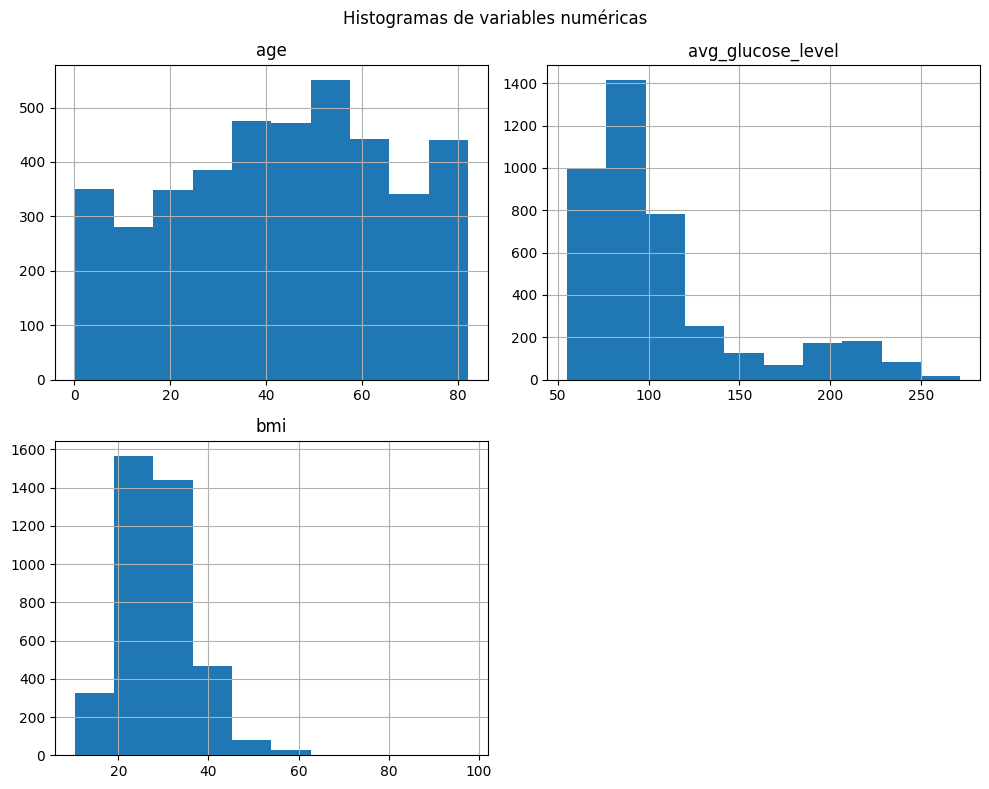

In [77]:
show_num[['age', 'avg_glucose_level', 'bmi']].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

C:\Users\juana\AppData\Local\Temp\ipykernel_3992\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juana\A

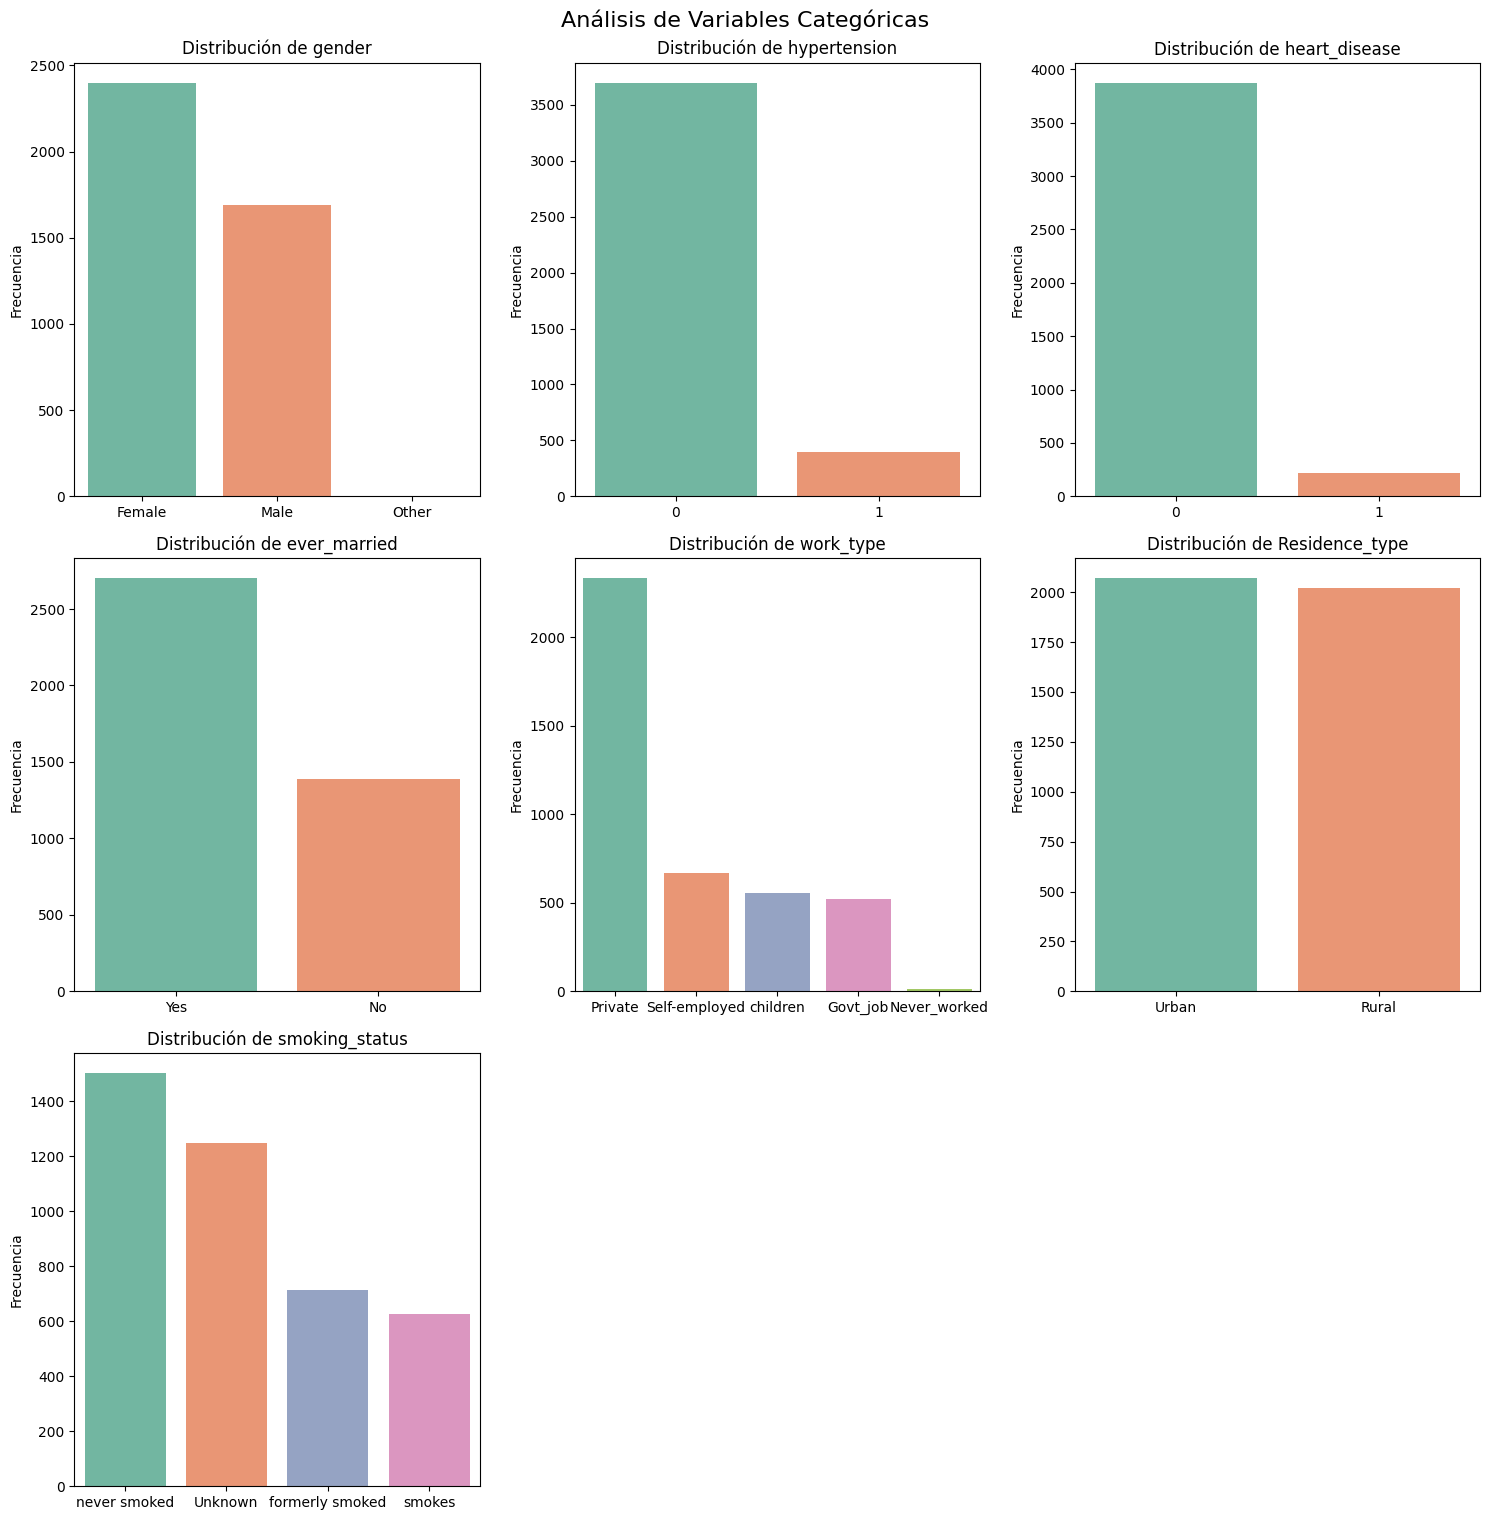

In [78]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']

show_cat = X_train[categorical_cols].copy()
show_cat['stroke'] = y_train.values

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = show_cat[col].value_counts().index
    sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
    
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Análisis de Variables Categóricas", fontsize=16, y=1.01)
plt.show()

**Análisis y decisión sobre datos faltantes y outliers**

In [79]:
# Outliers

limite_bmi = 80 # valores por encima de este limite se consideran outliers
X_train.loc[X_train['bmi'] > limite_bmi, 'bmi'] = np.nan

REVISAR

Contexto Médico: En medicina, un BMI > 60 se considera "Súper-Súper Obesidad". Son casos donde la fisiología cambia drásticamente y podrían actuar como ruido para la Red Neuronal, pero mantenés a todos los pacientes con obesidad "estándar" y "mórbida" (BMI 30-50) que son vitales para predecir un ACV.

Simplicidad: Es más fácil de explicar en tu informe del TP: "Se decidió filtrar solo valores superiores a 60 para eliminar ruido extremo sin perder la representatividad de pacientes obesos".

In [80]:
# Columnas que vas a usar para imputar
cols = ['age', 'avg_glucose_level', 'bmi']

imputer = KNNImputer(n_neighbors=5)

imputer.fit(X_train[cols])

X_train[cols] = imputer.transform(X_train[cols])
X_test[cols] = imputer.transform(X_test[cols])

In [81]:
X_test.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

**División y elección de variables importantes**

In [82]:
# fijarse esto
cols = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status']

X_train = X_train[cols]
X_test  = X_test[cols]

**Codificación de variables categóricas**

In [83]:
X_all = pd.concat([X_train, X_test], axis=0)
X_all = pd.get_dummies(X_all, drop_first=True)

X_train = X_all.iloc[:len(X_train), :].reset_index(drop=True)
X_test  = X_all.iloc[len(X_train): , :].reset_index(drop=True)

**Visualización de datos** (posterior a la imputación)

In [84]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

show_num = X_train[numerical_cols].copy()
show_num['stroke'] = y_train.values

C:\Users\juana\AppData\Local\Temp\ipykernel_3992\1033301395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\1033301395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_3992\1033301395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


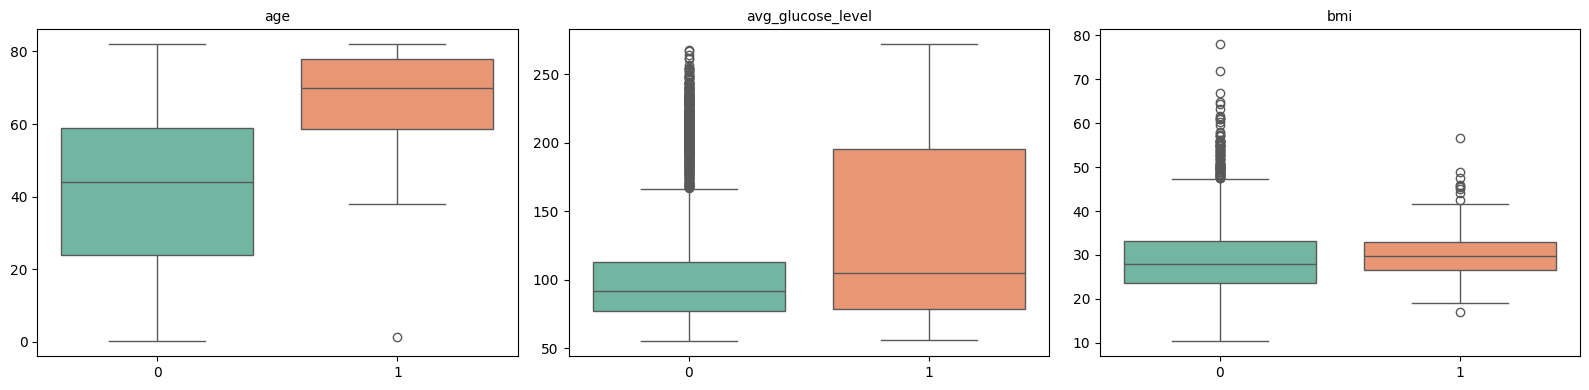

In [85]:
cols = 3
num_vars = len(show_num.columns) - 1
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns[:-1]): 
    sns.boxplot(
        data=show_num,
        x='stroke', 
        y=var,
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

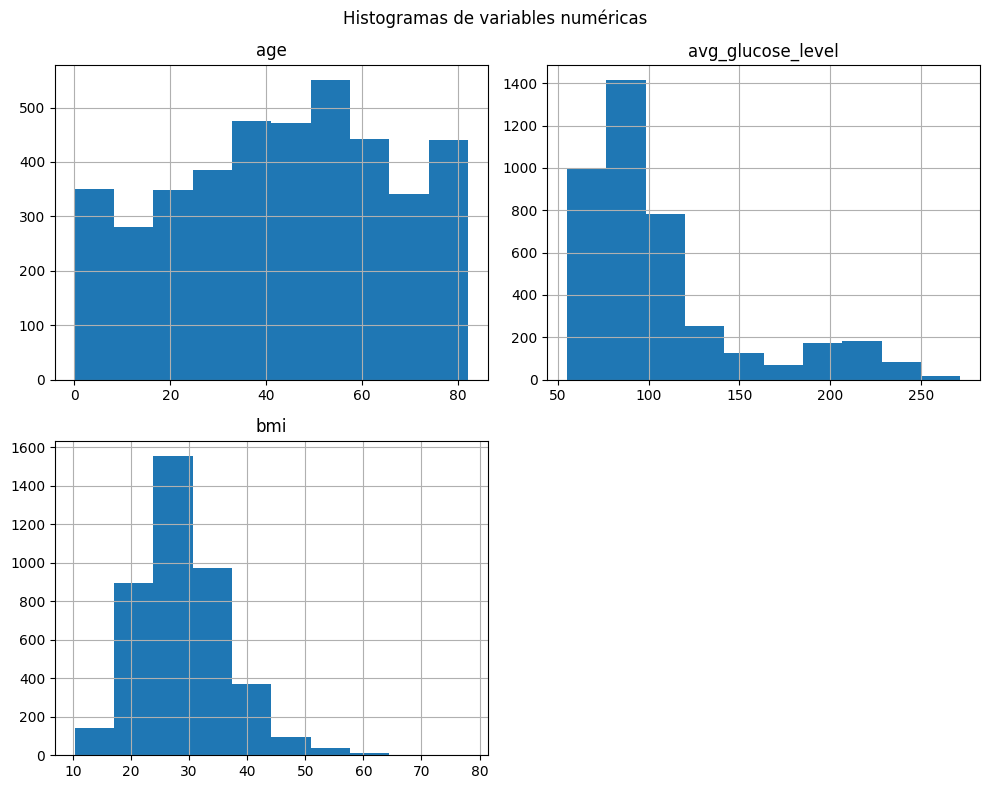

In [86]:
show_num.drop(columns='stroke', inplace=True)

show_num.hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

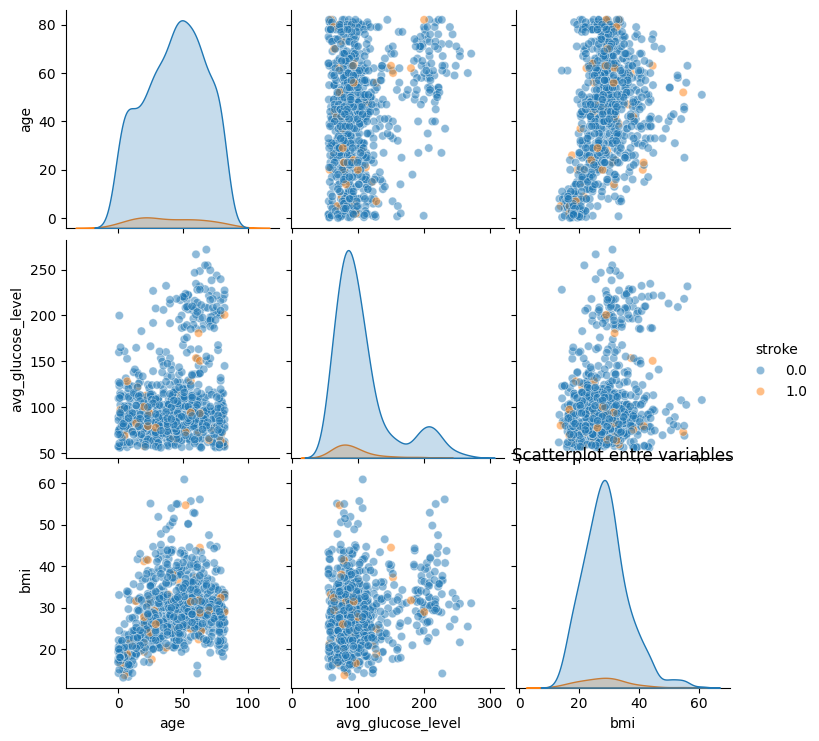

In [87]:
pshow = show_num.copy()
pshow['stroke'] = y_train
sns.pairplot(pshow.sample(1000, random_state=1), hue='stroke', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.title('Scatterplot entre variables')
plt.show()

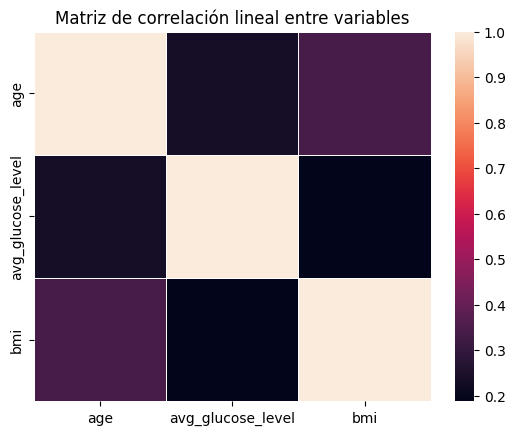

In [88]:
corrmat = show_num.corr()
sns.heatmap(corrmat, vmax=1, linewidths=.5)
plt.title('Matriz de correlación lineal entre variables')
plt.show()

In [89]:
X_train.isna().sum()

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

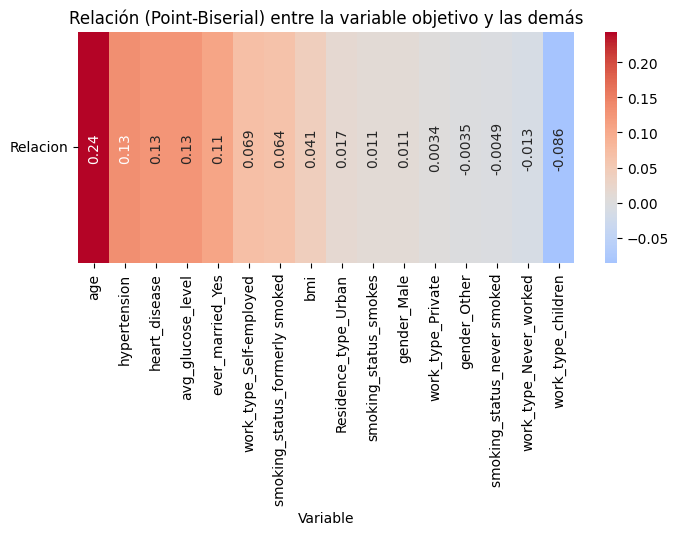

In [90]:
def relacion(X_train, y_train):
    resultados = []

    for col in X_train.columns:
        corr, _ = pointbiserialr(X_train[col], y_train)
        resultados.append({'Variable': col, 'Relacion': corr})
    
    return pd.DataFrame(resultados).sort_values(by='Relacion', ascending=False)

df_corr = relacion(X_train, y_train)
df_corr = df_corr.set_index("Variable")

plt.figure(figsize=(len(df_corr)*0.5, 3))
sns.heatmap(
    df_corr[["Relacion"]].T,
    annot=True,
    cmap="coolwarm",
    center=0,
    annot_kws={"rotation": 90, "va": "center", "ha": "center"}
)
plt.title("Relación (Point-Biserial) entre la variable objetivo y las demás")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

**Estandarización/escalado de datos.**

In [91]:
#Estandarizamos las columnas (ya son todas numéricas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Análisis del balance de clases**

In [92]:
train_counts = y_train.value_counts().rename("Cantidad_train")
train_perc = (y_train.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_train")

test_counts = y_test.value_counts().rename("Cantidad_test")
test_perc = (y_test.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_test")

tabla_balance = pd.concat([train_counts, train_perc, test_counts, test_perc], axis=1)
tabla_balance.index.name = "Clase"
display(tabla_balance)

,Cantidad_train,Porcentaje_train,Cantidad_test,Porcentaje_test
Clase,,,,
0,3889,95.13,972,95.11
1,199,4.87,50,4.89


In [93]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Antes:", y_train.value_counts())
print("Después:", pd.Series(y_train_res).value_counts())

Antes: stroke
0    3889
1     199
Name: count, dtype: int64
Después: stroke
0    3889
1    3889
Name: count, dtype: int64


CORREGIR

Resumen de recomendación
Para una red neuronal, la mejor práctica suele ser:

No usar SMOTE de entrada (a veces introduce ruido en espacios de alta dimensionalidad).

Empezar aplicando Class Weights en la función de pérdida.

Si eso no es suficiente, intentar Data Augmentation (si el dominio lo permite).

Usar Focal Loss si el desbalance es extremo.

¿Qué tipo de datos tiene tu dataset (imágenes, tablas, texto) y qué tan grande es el desbalance entre las clases?

### Implementación de la Red Neuronal

In [94]:
class ClasificacionBinariaNet_PyTorch(nn.Module):

    def __init__(self, input_dim=20, dropout_rate=0.3):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)
        )

        self._init_pesos()

    def _init_pesos(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.red(x).squeeze(1)
    
modelo_bin = ClasificacionBinariaNet_PyTorch(input_dim=20, dropout_rate=0.3)

In [ ]:
def entrenar_pytorch_clasificacion(modelo, X_train, y_train, X_test, y_test,
                                   es_binario=True, epochs=200,
                                   batch_size=32, lr=1e-3,
                                   weight_decay=1e-4, patience=20):

    # 1. FIX DE DIMENSIONES Y TIPOS
    X_tr = torch.tensor(np.array(X_train), dtype=torch.float32)
    X_te = torch.tensor(np.array(X_test),  dtype=torch.float32)
    y_tr = torch.tensor(np.array(y_train), dtype=torch.float32)
    y_te = torch.tensor(np.array(y_test),  dtype=torch.float32)

    # 2. OPTIMIZACIÓN DE RECALL: Pesamos más la clase positiva (1)
    # Aunque uses SMOTE, darle un peso de 2.0 o 3.0 fuerza a la red a priorizar el Recall
    pos_weight = torch.tensor([2.0]) 
    criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    historial = {'train_loss': [], 'test_loss': [], 'train_recall': [], 'test_recall': []}
    mejor_loss = float('inf')
    mejor_pesos = None
    espera = 0

    for epoca in range(epochs):
        modelo.train()
        train_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for Xb, yb in loader:
            pred = modelo(Xb)
            loss = criterio(pred, yb)
            
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()
            
            train_loss += loss.item()
            
            # Guardamos predicciones para Recall (usando threshold 0.5 por ahora)
            preds_labels = (torch.sigmoid(pred) > 0.5).float()
            all_train_preds.extend(preds_labels.numpy())
            all_train_labels.extend(yb.numpy())

        train_loss /= len(loader)
        train_rec = recall_score(all_train_labels, all_train_preds)

        # EVALUACIÓN
        modelo.eval()
        with torch.no_grad():
            pred_test = modelo(X_te)
            test_loss = criterio(pred_test, y_te).item()
            
            preds_labels_test = (torch.sigmoid(pred_test) > 0.5).float()
            test_rec = recall_score(y_te.numpy(), preds_labels_test.numpy())

        historial['train_loss'].append(train_loss)
        historial['test_loss'].append(test_loss)
        historial['train_recall'].append(train_rec)
        historial['test_recall'].append(test_rec)

        if test_loss < mejor_loss:
            mejor_loss = test_loss
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0
        else:
            espera += 1

        if (epoca + 1) % 20 == 0:
            print(f"Ep {epoca+1:3d} | Loss: {test_loss:.4f} | Test Recall: {test_rec:.4f}")

        if espera >= patience:
            print(f"\nEarly stopping en época {epoca+1}")
            break

    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
    return historial

¿Por qué ReLU? Porque evita el desvanecimiento del gradiente, permitiendo que la red aprenda más rápido que con funciones tanh o sigmoid en capas ocultas.

¿Por qué Adam? Porque combina las ventajas de AdaGrad y RMSProp, manejando tasas de aprendizaje adaptativas para cada parámetro, lo que lo hace ideal para datos tabulares clínicos.

¿Por qué Dropout + Weight Decay? Es una estrategia de "cinturón y aire acondicionado". El Dropout evita la co-adaptación de neuronas y el Weight Decay mantiene los pesos pequeños, garantizando que el modelo sea lo más simple (y generalizable) posible.

### Entrenamiento y curva de aprendizaje

In [ ]:
input_dim_real = X_train_res.shape[1] 
modelo_bin = ClasificacionBinariaNet_PyTorch(input_dim=input_dim_real, dropout_rate=0.3)

historial_bin_pt = entrenar_pytorch_clasificacion(
    modelo_bin,
    X_train_res, y_train_res, 
    X_test_scaled, y_test
)

Ep  20 | Loss: 0.6758 | Test Recall: 0.7800
Ep  40 | Loss: 0.7250 | Test Recall: 0.7400

Early stopping en época 46


In [97]:
def graficar_curvas(historial):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    epocas = range(1, len(historial['train_loss']) + 1)

    # Gráfico de Loss
    axes[0].plot(epocas, historial['train_loss'], label='Train Loss')
    axes[0].plot(epocas, historial['test_loss'], label='Test Loss')
    axes[0].set_title('Pérdida (BCE con Pesos)')
    axes[0].legend()

    # Gráfico de RECALL
    axes[1].plot(epocas, historial['train_recall'], label='Train Recall', color='green')
    axes[1].plot(epocas, historial['test_recall'], label='Test Recall', color='orange')
    axes[1].set_title('Métrica Objetivo: Recall (Sensibilidad)')
    axes[1].set_ylabel('Recall Score')
    axes[1].legend()

    plt.show()

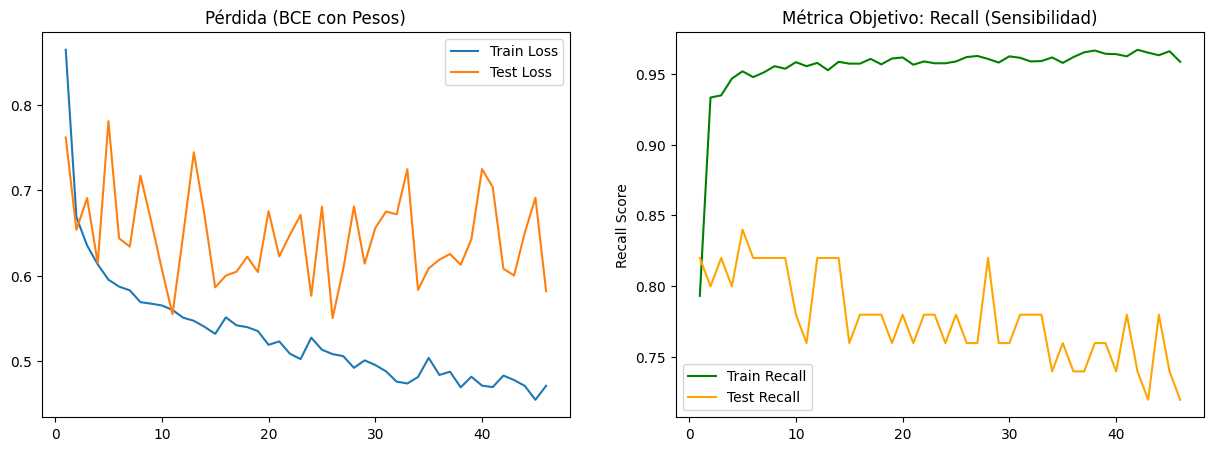


Arquitectura del modelo PyTorch (Clasificación Binaria):
ClasificacionBinariaNet_PyTorch(
  (red): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parámetros entrenables: 3,393


In [98]:
graficar_curvas(historial_bin_pt)
    

print(f"\nArquitectura del modelo PyTorch (Clasificación Binaria):")
print(modelo_bin)
total_params_b = sum(p.numel() for p in modelo_bin.parameters() if p.requires_grad)
print(f"\nTotal de parámetros entrenables: {total_params_b:,}")

### Evaluación del modelo

In [115]:
def graficar_roc_curve(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.3f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

Recall:  0.7600
AUC-ROC: 0.8098

Reporte de Clasificación:
                precision    recall  f1-score   support

Sin Riesgo ACV       0.98      0.73      0.84       972
    Riesgo ACV       0.13      0.76      0.22        50

      accuracy                           0.73      1022
     macro avg       0.55      0.74      0.53      1022
  weighted avg       0.94      0.73      0.81      1022



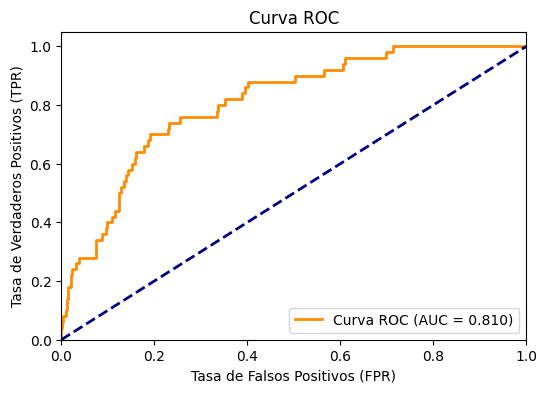

In [117]:
modelo_bin.eval()

with torch.no_grad():
    X_te_tensor = torch.tensor(np.array(X_test_scaled), dtype=torch.float32)
    logits_test = modelo_bin(X_te_tensor)
    
    probs_test = torch.sigmoid(logits_test).numpy() 
    preds_test = (probs_test > 0.5).astype(int)

recall = recall_score(y_test, preds_test)
auc_roc = roc_auc_score(y_test, probs_test)

print(f"Recall:  {recall:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, preds_test, 
                            target_names=['Sin Riesgo ACV', 'Riesgo ACV']))

# FIX: En lugar de predict_proba, usamos probs_test que ya definimos arriba
graficar_roc_curve(y_test, probs_test)

### Matriz de confusión

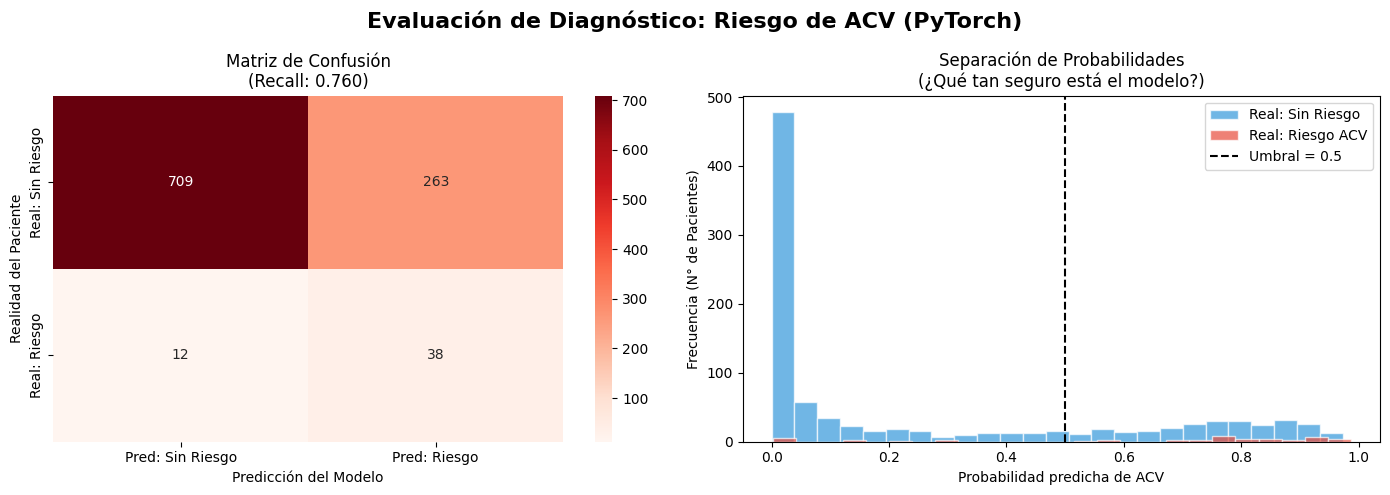

Verdaderos Negativos (TN): 709 — Pacientes sanos identificados correctamente.
Falsos Positivos (FP): 263 — Pacientes sanos que el modelo marcó como riesgo.
Falsos Negativos (FN): 12 — PACIENTES CON RIESGO NO DETECTADOS.
Verdaderos Positivos (TP): 38 — Pacientes con riesgo identificados correctamente.


In [121]:
cm = confusion_matrix(y_test, preds_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación de Diagnóstico: Riesgo de ACV (PyTorch)', fontweight='bold', fontsize=16)

# --- Subplot 1: Matriz de Confusión ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Pred: Sin Riesgo', 'Pred: Riesgo'],
            yticklabels=['Real: Sin Riesgo', 'Real: Riesgo'])
axes[0].set_title(f'Matriz de Confusión\n(Recall: {recall:.3f})')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad del Paciente')

# --- Subplot 2: Distribución de Probabilidades ---
axes[1].hist(probs_test[y_test==0], bins=25, alpha=0.7, color='#3498db',
             label='Real: Sin Riesgo', edgecolor='white')
axes[1].hist(probs_test[y_test==1], bins=25, alpha=0.7, color='#e74c3c',
             label='Real: Riesgo ACV', edgecolor='white')

axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral = 0.5')
axes[1].set_xlabel('Probabilidad predicha de ACV')
axes[1].set_ylabel('Frecuencia (N° de Pacientes)')
axes[1].set_title('Separación de Probabilidades\n(¿Qué tan seguro está el modelo?)')
axes[1].legend()

plt.tight_layout()
plt.show()


print(f"Verdaderos Negativos (TN): {cm[0,0]} — Pacientes sanos identificados correctamente.")
print(f"Falsos Positivos (FP): {cm[0,1]} — Pacientes sanos que el modelo marcó como riesgo.")
print(f"Falsos Negativos (FN): {cm[1,0]} — PACIENTES CON RIESGO NO DETECTADOS.")
print(f"Verdaderos Positivos (TP): {cm[1,1]} — Pacientes con riesgo identificados correctamente.")

### Análisis y conclusiones